In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

df = pd.read_csv('../data/raw/ab_test.csv')
df.head()


,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [6]:
df.info

<bound method DataFrame.info of             id     time  con_treat      page  converted
0       851104  11:48.6    control  old_page          0
1       804228  01:45.2    control  old_page          0
2       661590  55:06.2  treatment  new_page          0
3       853541  28:03.1  treatment  new_page          0
4       864975  52:26.2    control  old_page          1
...        ...      ...        ...       ...        ...
294473  751197  28:38.6    control  old_page          0
294474  945152  51:57.1    control  old_page          0
294475  734608  45:03.4    control  old_page          0
294476  697314  20:29.0    control  old_page          0
294477  715931  40:24.5  treatment  new_page          0

[294478 rows x 5 columns]>

In [7]:
df.describe()

,id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [8]:
df.isnull().sum()

id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

In [10]:
print(df['con_treat'].value_counts())
print()
print(df['page'].value_counts())
print()
print(df['converted'].value_counts())

con_treat
treatment    147276
control      147202
Name: count, dtype: int64

page
old_page    147239
new_page    147239
Name: count, dtype: int64

converted
0    259241
1     35237
Name: count, dtype: int64


In [11]:
print(df.groupby(['con_treat', 'page']).size())

con_treat  page    
control    new_page      1928
           old_page    145274
treatment  new_page    145311
           old_page      1965
dtype: int64


### EDA Initial Findings:

 * **294,478** rows without nulls
 * Groups are perfectly balanced: **treatment 147,726 / control 147,202**
 * New page count indicates some treatment users were shown the old page due to an error -> **old page -> 147,239 & new page -> 147,239**
    * 1928 control users saw the new page
    * 1965 treatment users saw the old page
 * Conversion rate: 35,237 / 294,478 = **~12%**



## 1 - Data Cleaning

In [ ]:
df_clean = df[((df['con_treat'] == 'treatment') & (df['page'] == 'new_page')) | ((df['con_treat'] == 'control') & (df['page'] == 'old_page'))]

In [35]:
print( f'Dropped number of rows: {df.shape[0] - df_clean.shape[0]}')
print( f'Dropped percentage: {round((df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100, 2)}%')

Dropped number of rows: 3893
Dropped percentage: 1.32%


In [20]:
print(df_clean.shape)
print('')
print(df_clean.groupby(['con_treat','page']).size())

(290585, 5)

con_treat  page    
control    old_page    145274
treatment  new_page    145311
dtype: int64


***Checking Duplicate Users***

In [42]:
print(f'Duplicate user IDs: {df_clean["id"].duplicated().sum()}')
print()
df_clean[df_clean["id"].duplicated() == True]

Duplicate user IDs: 1



,id,time,con_treat,page,converted
2893,773192,55:59.6,treatment,new_page,0


In [43]:
df_clean = df_clean.drop_duplicates(subset='id', keep=False)

## 2 - True Conversion Rates

In [55]:
conversion_rates = df_clean.groupby('con_treat')['converted'].agg(['mean','sum','count'])
conversion_rates.columns = ['conversion_rate','conversions','total']
conversion_rates['conversion_rate'] = (conversion_rates['conversion_rate'] * 100).round(3)

In [57]:
conversion_rates

,conversion_rate,conversions,total
con_treat,,,
control,12.039,17489,145274
treatment,11.881,17264,145309


*The results indicate the new page is performing slightly worse than the old page and suggests there is no significant impact on conversion.*

### 2.1 Conversion Rate Plot

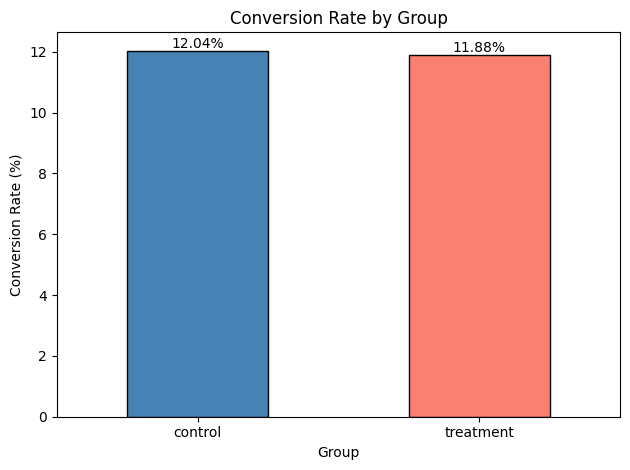

In [58]:
ax = conversion_rates['conversion_rate'].plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Conversion Rate by Group')
plt.xlabel('Group')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3 - EDA Summary

* Raw dataset: **294,478 rows**
* Dropped **3,893 mismatched rows** (~1.3%) and 1 duplicate user ID
* Cleaned dataset: **290,584 rows**, perfectly balanced treatment and control groups
* Control conversion rate: **12.04%**
* Treatment conversion rate: **11.84%**
* Difference: new page performs worse by **-0.16%**

## 4 - Hypothesis Testing 

## Hypothesis Testing Framework

We never prove H1 directly. Instead, we test whether the data gives us enough 
evidence to reject H0.

- **H0 (null):** the default assumption, no effect, nothing changed
- **H1 (alternative):** what we want to prove, the new page performs better

**Decision rule:**
- If p-value < α → reject H0, result is statistically significant
- If p-value ≥ α → fail to reject H0, not enough evidence

Failing to reject H0 does not mean H0 is true. It just means the data 
did not provide sufficient evidence against it.

In [62]:
n_control = df_clean[df_clean['con_treat'] == 'control'].shape[0]
n_treatment = df_clean[df_clean['con_treat'] == 'treatment'].shape[0]

conv_control = df_clean[df_clean['con_treat'] == 'control']['converted'].sum()
conv_treatment = df_clean[df_clean['con_treat'] == 'treatment']['converted'].sum()

p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment 

p_pool = (conv_control + conv_treatment) / (n_control + n_treatment)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_treatment))

z_score = (p_treatment - p_control) / se
p_value = stats.norm.cdf(z_score)

print(f'Z-score: {round(z_score,4)}')
print(f'P-value: {round(p_value, 4)}')
print(f'\nConclusion: {"Reject H0" if p_value < 0.05 else "Fail to reject H0"}')

Z-score: -1.3102
P-value: 0.0951

Conclusion: Fail to reject H0


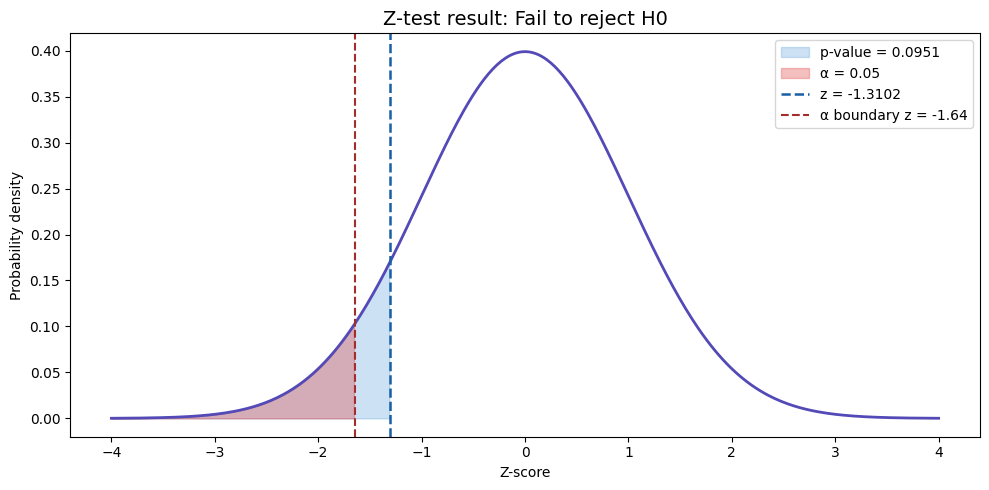

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

z_obs = -1.3102
z_alpha = stats.norm.ppf(0.05)  # -1.6449
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))

# Main curve
ax.plot(x, y, color='#534AB7', linewidth=2)

# p-value shading
ax.fill_between(x, y, where=(x <= z_obs), color='#3B8BD4', alpha=0.25, label=f'p-value = 0.0951')

# alpha shading
ax.fill_between(x, y, where=(x <= z_alpha), color='#E24B4A', alpha=0.35, label=f'α = 0.05')

# z_obs line
ax.axvline(z_obs, color='#185FA5', linestyle='--', linewidth=1.8, label=f'z = {z_obs}')

# z_alpha line
ax.axvline(z_alpha, color='#A32D2D', linestyle='--', linewidth=1.5, label=f'α boundary z = {round(z_alpha, 2)}')

ax.set_title('Z-test result: Fail to reject H0', fontsize=14)
ax.set_xlabel('Z-score')
ax.set_ylabel('Probability density')
ax.legend()
plt.tight_layout()
plt.show()

## 5 - Power Analysis

In [70]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize 

# baseline conversion rate 
p_control = 0.12039

# MDE - What lift would be practically meaningful? -> 1pp assumption
p_treatment_assumed = 0.13039

# effect size (Cohen's h)
effect_size = proportion_effectsize(p_treatment_assumed, p_control)

# required sample size per group
analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size = effect_size, alpha=0.05, power=0.8, alternative='larger')

# actual power of the test 
actual_power = analysis.solve_power(effect_size=effect_size,alpha=0.05, nobs1=n_control)

print(f'Effect size (Cohens h): {round(effect_size, 4)}')
print(f'Required n per group (for 80% power): {round(required_n)}')
print(f'Actual n per group: {n_control}')
print(f'Actual power of the test: {round(actual_power, 4)}')


Effect size (Cohens h): 0.0302
Required n per group (for 80% power): 13556
Actual n per group: 145274
Actual power of the test: 1.0


### 5A - Power Analysis Findings

* Minimum Detectable Effect (MDE) set at 1pp lift is realistic
* Cohen's h = 0.0302 confirms 1pp lift is a small effect in standardized terms
* Required sample size to achieve 80% power: ~13,556 per group. Actual sample size is 10x
* Actual power of the test: 100%
* ***Conclusion: the test is overpowered for 1 pp MDE. There is enough data that proves the new page does not drive a meaningful lift in conversion.***




--------------------------
*Why Cohen's h?*

Cohen's h tells us the magnitude of the difference relative to the scale of the proportions.

* **h = 0.0302** indicates that assumed conversion lift is a small effect in standardized terms.
* The baseline is low: 12%
* 1pp change is modest
* Cohen's scale: h < 0.2 = small, 0.2-0.5 = medium, > 0.5 = large

--------------------------


## 6 - Logistic Regression 

In [72]:
import statsmodels.api as sm

# encode treatment as binary
df_clean['is_treatment'] = (df_clean['con_treat'] == 'treatment').astype(int)

# define X and y
X = sm.add_constant(df_clean['is_treatment'])
y = df_clean['converted']

# fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.366119
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               290583
Model:                          Logit   Df Residuals:                   290581
Method:                           MLE   Df Model:                            1
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:               8.068e-06
Time:                        11:56:57   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1901
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.9888      0.008   -246.669      0.000      -2.005      -1.973
is_treatment    -0.0150

### 6A - The Analysis of the Result

* P-value of 0.190 (two-tailed) is consistent with the z-test result: 0.190 x 2 -> 0.950 and not significant.
* Pseudo R-squared value of 0.000008 does not provide any explanations for the variation in conversion.
* Confidence Interval: **[-0.037, 0.007]** -> Interval crosses zero without significant effect.


----------

The confidence interval (CI) provides the range of plausible values for the true coefficient.

For this data, we are 95% confident that the true coefficient for the treatment flag is between -0.037 and 0.007

* when the interval is completely negative (-0.0037 and -0.005) -> treatment reliably hurts conversion
* when the interval is completely positive (0.0037 and 0.005) -> treatment helps conversion
* when the interval crosses zero -> it can't be ruled out that the impact is exactly zero without significance
  
-----------

#### 6A1 - Odds Ratio

***How to interpret Odds Ratio?***

* When > 1, treatment increases odds of conversion
* When = 1, no difference
* When < 1, treatment decreases odds of conversion

In [78]:
import numpy as np

odds_ratio = np.exp(result.params['is_treatment'])
print(f'Odds ratio: {round(odds_ratio, 4)}')

Odds ratio: 0.9851


* Odds ratio is below 1; therefore, the new page might be slightly hurting the conversion. Treatment users are 1.49% less likely to convert. This is highly likely a random noise as CI crossing zero and the p-value is 0.19 without statistical significance.

## Logistic Regression Summary

- Group assignment encoded as binary: treatment = 1, control = 0
- Coefficient on is_treatment: -0.0150 (negative, confirming treatment converts slightly less than control)
- P-value: 0.190 (two-tailed, consistent with z-test one-tailed p-value of 0.0951)
- 95% confidence interval: [-0.037, 0.007] — crosses zero, no significant effect
- Odds ratio: 0.9851 — treatment users are 1.49% less likely to convert than control users
- Pseudo R-squared: ~0 — expected in a single-predictor A/B test, group assignment alone explains almost none of the variation in conversion
- Conclusion: logistic regression confirms the z-test result. The new page does not significantly affect conversion rate

## 7 - Practical Significance

To be able to understand whether financially it would make sense to implement the changes to the old page with the actual difference of -0.16pp and the MDE difference of 1pp lift, we still need to calculate the potential revenue impact. The calculations are performed based on the following assumptions:

- AOV: 50
- Monthly Visitors: 290,000

In [85]:
# Assumptions 
avg_order_value = 50
monthly_visitors = 290000

# Observed difference
p_control = 0.1204
p_treatment = 0.1188
observed_diff = p_treatment - p_control # -0.0016

# MDE assumed difference
mde_diff = 0.01 #1pp lift

# Current monthly revenue (baseline)
baseline_revenue = monthly_visitors * p_control * avg_order_value 

# Revenue under treatment (actual)
actual_treatment_revenue = monthly_visitors * p_treatment * avg_order_value 
actual_impact = actual_treatment_revenue - baseline_revenue

# Revenue under treatment(based on MDE)
mde_treatment_revenue = monthly_visitors * (p_control + mde_diff) * avg_order_value
mde_impact = mde_treatment_revenue - baseline_revenue 

print(f'Baseline monthly revenue:        ${baseline_revenue:,.0f}')
print(f'\nActual observed difference:      {round(observed_diff * 100, 2)}pp')
print(f'Revenue impact (actual):         ${actual_impact:,.0f}/month')
print(f'Revenue impact (actual):         ${actual_impact * 12:,.0f}/year')
print(f'\nAssumed MDE difference:          1pp')
print(f'Revenue impact (MDE):            ${mde_impact:,.0f}/month')
print(f'Revenue impact (MDE):            ${mde_impact * 12:,.0f}/year')

Baseline monthly revenue:        $1,745,800

Actual observed difference:      -0.16pp
Revenue impact (actual):         $-23,200/month
Revenue impact (actual):         $-278,400/year

Assumed MDE difference:          1pp
Revenue impact (MDE):            $145,000/month
Revenue impact (MDE):            $1,740,000/year


## 8 - Conclusion


- Actual observed difference (-0.16pp) implies a potential revenue loss of $23,200/month 
  ($278,400/year). However, since this difference is not statistically significant, it 
  cannot be attributed to the new page with confidence. It's likely noise.
- Had the new page achieved the MDE of 1pp lift, it would have generated an additional 
  $145,000/month ($1,740,000/year).

**Recommendation**

- Do not ship the new page
- The test was well-powered — with ~145k users per group, a real 1pp lift would have 
  been detected with near certainty. Failing to reject H0 is conclusive, not inconclusive.
- The new page should be redesigned before running another experiment